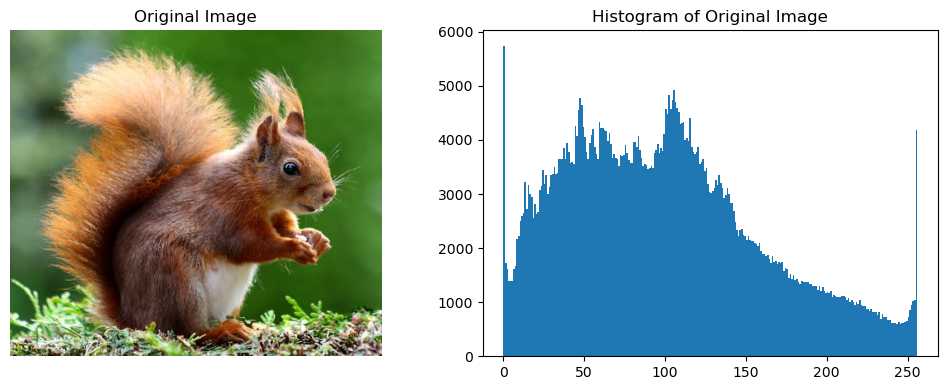

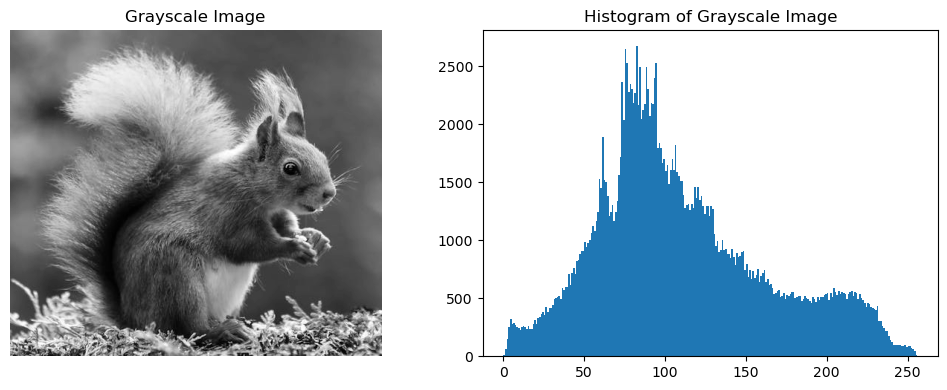

In [33]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random

# Utility function for displaying image + histogram
def show_image_and_hist(image, title, cmap=None):
    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.imshow(image, cmap=cmap)
    plt.title(title)
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.hist(image.ravel(), bins=256, range=[0,256])
    plt.title(f"Histogram of {title}")

    plt.tight_layout()
    plt.show()

# Load the image (color)
img = cv2.imread(r"fdip2.jpeg")

if img is None:
    raise FileNotFoundError("Image not found! Check path/extension")

# Convert from BGR (OpenCV) to RGB (for matplotlib display)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Display Original Color Image
show_image_and_hist(img_rgb, "Original Image", cmap=None)

# Convert to Grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
show_image_and_hist(gray, "Grayscale Image", cmap='gray')



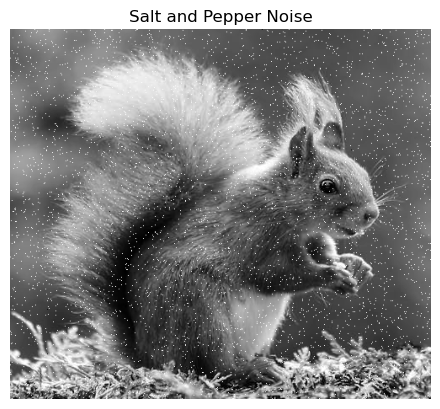

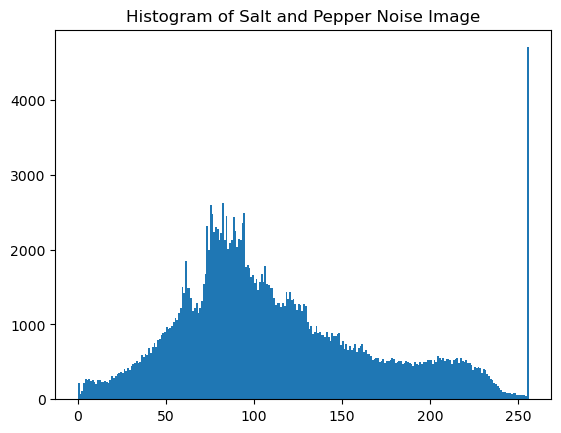

In [35]:
import random
import cv2
import matplotlib.pyplot as plt

# Load grayscale image
salt_and_paper = cv2.imread(r"fdip2.jpeg", cv2.IMREAD_GRAYSCALE)

if salt_and_paper is None:
    raise FileNotFoundError("Image not found! Check filename or path")

row, col = salt_and_paper.shape

# Add Salt (white pixels)
number_of_pixels = random.randint(1000, 10000)
for i in range(number_of_pixels):
    y_coord = random.randint(0, row - 1)
    x_coord = random.randint(0, col - 1)
    salt_and_paper[y_coord][x_coord] = 255

# Add Pepper (black pixels)
number_of_pixels = random.randint(1, 10)
for i in range(number_of_pixels):
    y_coord = random.randint(0, row - 1)
    x_coord = random.randint(0, col - 1)
    salt_and_paper[y_coord][x_coord] = 0

# Show noisy image
plt.title("Salt and Pepper Noise")
plt.imshow(salt_and_paper, cmap='gray')
plt.axis("off")
plt.show()

# Show histogram
plt.hist(salt_and_paper.ravel(), bins=256, range=[0,256])
plt.title("Histogram of Salt and Pepper Noise Image")
plt.show()


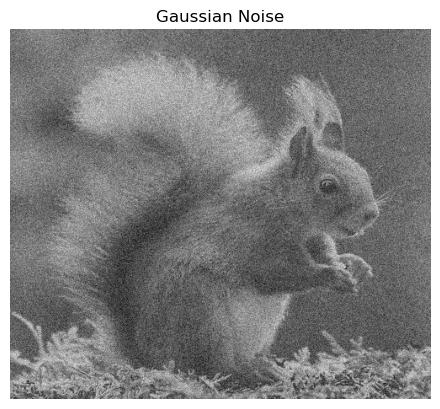

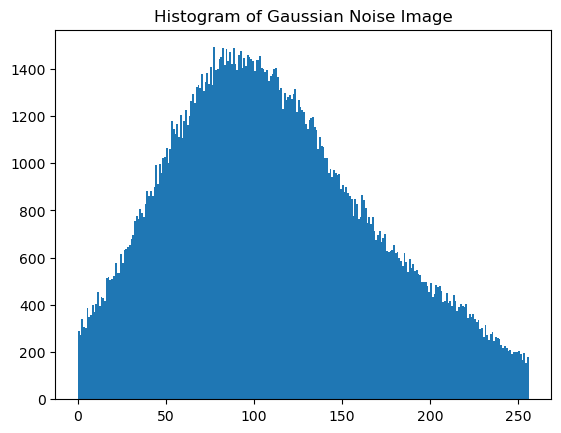

In [43]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load grayscale image
img = cv2.imread(r"fdip2.jpeg", cv2.IMREAD_GRAYSCALE)

# Gaussian noise parameters
mean = 0
std_dev = 35

# Generate Gaussian noise
gaussian_noise = np.random.normal(loc=mean, scale=std_dev, size=img.shape).astype(np.float32)

# Add noise to image
gaussian_img = img.astype(np.float32) + gaussian_noise


# Show noisy image
plt.title("Gaussian Noise")
plt.imshow(gaussian_img, cmap='gray')
plt.axis("off")
plt.show()

# Show histogram
plt.hist(gaussian_img.ravel(), bins=256, range=[0,256])
plt.title("Histogram of Gaussian Noise Image")
plt.show()


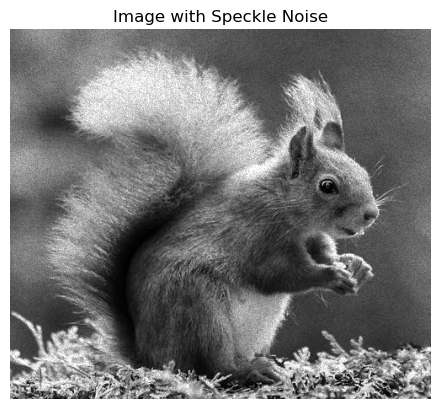

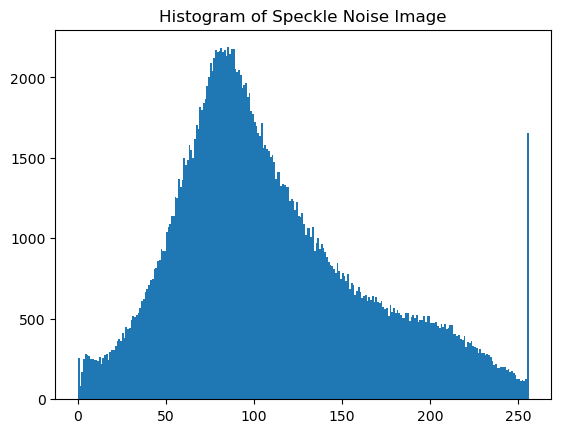

In [45]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load grayscale image
img = cv2.imread(r"fdip2.jpeg", cv2.IMREAD_GRAYSCALE)

if img is None:
    raise FileNotFoundError("Image not found! Check the path.")

# Generate Speckle noise (Gaussian with mean=0)
mean = 0
variance = 0.1   # smaller value -> less noisy
noise = np.random.normal(mean, variance, img.shape)

# Apply Speckle noise: image + image * noise
noisy_image = img.astype(np.float32) + img.astype(np.float32) * noise

# Clip values and convert back to uint8
noisy_image = np.clip(noisy_image, 0, 255).astype(np.uint8)

# Show noisy image
plt.imshow(noisy_image, cmap='gray')
plt.title("Image with Speckle Noise")
plt.axis("off")
plt.show()

# Show histogram
plt.hist(noisy_image.ravel(), bins=256, range=[0,256])
plt.title("Histogram of Speckle Noise Image")
plt.show()
